# [EN] Basic example of use - gridmarthe 101

The gridmarthe package is designed to facilitate reading/writing grids in the Marthe format.
This notebook allows you to explore some basic features of the package and shows an example
of grid processing.

In [30]:
# import package
import gridmarthe as gm

gridmarthe library is based on `xarray`, which enhances working with multidimensional grids. 
Full documentation is available at:
https://docs.xarray.dev/en/stable/index.html

## Basic features


Marthe Grids contain metadata, including the time step index,
but not the actual dates. Therefore, it is useful to provide the reading function
either with a series of dates (to be constructed manually) or a timestep file so that the dates are
read automatically.

Additionally, several arguments can be useful for reading (removal of null values, 
transformation of xy, addition of mesh indicator or column/row numbers, etc.).

To check for possible options, you can display the function's help.


In [31]:
help(gm.load_marthe_grid)

Help on function load_marthe_grid in module gridmarthe.grid.io.gridmarthe:

load_marthe_grid(filename: str, varname: Optional[str] = None, fpastp: Optional[str] = None, dates=None, drop_nan: bool = False, nan_value: Union[int, float, list, NoneType] = None, xyfactor: Union[int, float] = 1.0, shallow_only=False, add_col_row: bool = False, add_id_grid: bool = False, title: Optional[str] = None, var_attrs: dict = {}, epsg: int = 27572, full_3d: bool = False, drop_time: bool = False, model_attrs: dict = {'domain': 'FR-France', 'institution': 'BRGM, French Geological Survey, Orléans, France'}, engine: str = 'xarray', verbose: bool = False, **kwargs)
    Read Marthe Grid File as xarray.Dataset
    
    The gridfile is read as a sequence: the variable for all layer
    for main grid, then all layer for nested grids, is stored in
    a 1D vector for every timestep. A single spatial identifier
    ``zone`` is used to map spatial coordinates.
    
    Before plot operations, user can assign coor

In [32]:
# reading data and storing into Dataset object (with xarray)
ds = gm.load_marthe_grid(
    './data/chasim_hallue.out', 'CHARGE',
    fpastp='./data/hallue.pastp',
    drop_nan=True
)

In [33]:
# display values and attributes
display(ds)

<xarray.Dataset> Size: 2MB
Dimensions:  (time: 205, zone: 927)
Coordinates:
  * time     (time) datetime64[ns] 2kB 1995-07-31 1995-08-01 ... 2012-07-01
  * zone     (zone) int32 4kB 255 256 257 258 259 ... 2722 2723 2724 2725 2726
Data variables:
    charge   (time, zone) float64 2MB 100.0 100.6 101.1 ... 27.0 26.0 26.35
    x        (zone) float32 4kB 617.8 618.2 618.8 619.2 ... 606.8 607.2 607.8
    y        (zone) float32 4kB 2.567e+03 2.567e+03 ... 2.543e+03 2.543e+03
    dx       (zone) float32 4kB 0.5 0.5 0.5 0.5 0.5 0.5 ... 0.5 0.5 0.5 0.5 0.5
    dy       (zone) float32 4kB 0.5 0.5 0.5 0.5 0.5 0.5 ... 0.5 0.5 0.5 0.5 0.5
    izone    (zone) int32 4kB 1 2 3 4 5 6 7 8 ... 921 922 923 924 925 926 927
Attributes: (12/17)
    conventions:          CF-1.10
    title:                Modélisation du bassin de la SOMME Nappe_Libre
    marthe_grid_version:  9.0
    original_dimensions:  x,y,z [grids]: 53 54 1
    crs:                  {'crs_wkt': 'PROJCRS["NTF (Paris) / Lambert zone II...
    lon_resolution:       0.5
    ...                   ...
    period:               1995-2012
    frequency:            30 day(s)
    creation_date:        Created on 2026-04-30T11:35:03Z UTC
    comment:              Hydrogeological model created with MARTHE code (Thi...
    domain:               FR-France
    institution:          BRGM, French Geological Survey, Orléans, France

The grid is loaded into a 2D xarray object (reduced horizontal grid), with dimensions (time, zone).
The spatial dimension is thus 1D, contained in `zone`. Each zone has a pair of xy coordinates, stored as a variable (not as a dimension).
This format allows many operations to be performed more efficiently than in 2 or 3D + time.
You just need to assign the coordinates (transform to 2 or 3D + time) before using graphical features.


In [34]:
# add coordinates to transform the 2D Dataset into 3D
ds_3d = gm.assign_coords(ds)
display(ds_3d)  # check new coordinates

<xarray.Dataset> Size: 3MB
Dimensions:  (y: 48, x: 44, time: 205)
Coordinates:
  * y        (y) float32 192B 2.567e+03 2.566e+03 ... 2.544e+03 2.543e+03
  * x        (x) float32 176B 599.2 599.8 600.2 600.8 ... 619.8 620.2 620.8
  * time     (time) datetime64[ns] 2kB 1995-07-31 1995-08-01 ... 2012-07-01
Data variables:
    charge   (time, y, x) float64 3MB nan nan nan nan nan ... nan nan nan nan
    dx       (y, x) float32 8kB nan nan nan nan nan nan ... nan nan nan nan nan
    dy       (y, x) float32 8kB nan nan nan nan nan nan ... nan nan nan nan nan
    izone    (y, x) float64 17kB nan nan nan nan nan nan ... nan nan nan nan nan
Attributes: (12/17)
    conventions:          CF-1.10
    title:                Modélisation du bassin de la SOMME Nappe_Libre
    marthe_grid_version:  9.0
    original_dimensions:  x,y,z [grids]: 53 54 1
    crs:                  {'crs_wkt': 'PROJCRS["NTF (Paris) / Lambert zone II...
    lon_resolution:       0.5
    ...                   ...
    period:               1995-2012
    frequency:            30 day(s)
    creation_date:        Created on 2026-04-30T11:35:03Z UTC
    comment:              Hydrogeological model created with MARTHE code (Thi...
    domain:               FR-France
    institution:          BRGM, French Geological Survey, Orléans, France

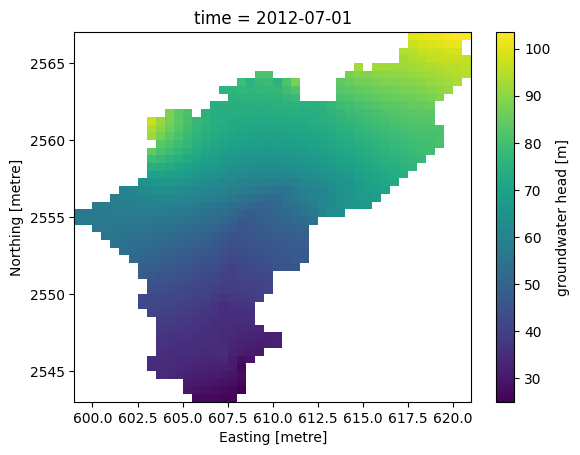

In [35]:
# plot for a given time step
ds_3d.isel(time=-1)['charge'].plot.pcolormesh()

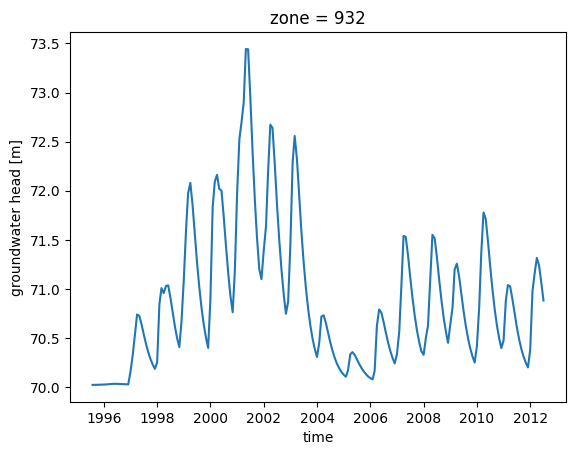

In [36]:
# or plot for a given zone (over time)
ds.isel(zone=255)['charge'].plot()

For nested grids, a specific plotting function is provided (`gm.plot_nested_grids()`).

For models with multiple layers, you can retrieve the surface layers: `gm.get_min_layer(ds, [subset_layers=[3,5]])`

or even display this result: `gm.plot_outcrop()`

The native functions of xarray and numpy already allow grid modifications (value substitution, transformation, operations between two grids, etc.)


## Advanced features

Handle computation over grids, with `xarray` and `gridmarthe`

In [37]:
# compute diff between grids
ds0 = ds.sel(time='1995-11-01')
ds1 = ds.sel(time='2001-02-01')

ds0['charge'] - ds1['charge']

<xarray.DataArray 'charge' (zone: 927)> Size: 7kB
array([ 0.00000e+00,  0.00000e+00,  0.00000e+00,  0.00000e+00,
        0.00000e+00,  0.00000e+00,  0.00000e+00,  0.00000e+00,
       -3.25440e-01, -4.60980e-01, -5.27480e-01, -5.59100e-01,
       -5.74500e-01,  0.00000e+00, -3.74970e-01, -6.81720e-01,
       -8.68420e-01, -9.77570e-01, -1.04721e+00, -1.09548e+00,
        0.00000e+00, -6.41230e-01, -1.00733e+00, -1.22240e+00,
       -1.35717e+00, -1.45930e+00, -1.57370e+00, -1.80513e+00,
        0.00000e+00,  0.00000e+00,  0.00000e+00,  0.00000e+00,
       -5.66100e-01, -1.02068e+00, -1.33316e+00, -1.53087e+00,
       -1.65762e+00, -1.74995e+00, -1.82523e+00, -1.90350e+00,
        0.00000e+00,  0.00000e+00, -1.43024e+00, -1.00962e+00,
       -1.14766e+00, -8.35060e-01, -7.87260e-01, -8.78120e-01,
       -1.16742e+00, -1.45697e+00, -1.68467e+00, -1.83483e+00,
       -1.92341e+00, -1.97372e+00, -1.99069e+00, -1.98500e+00,
        0.00000e+00,  0.00000e+00, -3.44370e-01, -3.57610e-01,
        0.00000e+00,  0.00000e+00,  0.00000e+00, -2.09688e+00,
       -1.83277e+00, -1.61107e+00, -1.55613e+00, -1.44464e+00,
       -1.43203e+00, -1.52037e+00, -1.68965e+00, -1.87151e+00,
       -2.02142e+00, -2.11349e+00, -2.14897e+00, -2.14145e+00,
       -2.09989e+00, -1.43919e+00, -1.36450e+00, -9.45770e-01,
...
       -6.78740e-01, -1.82235e+00, -1.73151e+00, -1.55717e+00,
       -1.30703e+00, -9.77720e-01, -5.57570e-01, -4.35400e-02,
       -1.44860e-01, -2.52990e-01, -3.26250e-01, -3.69900e-01,
       -4.01230e-01, -5.87460e-01, -6.72990e-01, -1.76108e+00,
       -1.67109e+00, -1.50200e+00, -1.26479e+00, -9.60430e-01,
       -5.85770e-01, -1.32270e-01, -3.03400e-02, -1.52940e-01,
       -1.90000e-01, -1.65750e-01,  0.00000e+00, -1.76839e+00,
       -1.72637e+00, -1.62543e+00, -1.45758e+00, -1.23024e+00,
       -9.55270e-01, -6.37120e-01, -3.04530e-01, -2.48100e-02,
       -7.04900e-02,  0.00000e+00,  0.00000e+00, -1.75184e+00,
       -1.68804e+00, -1.58243e+00, -1.41312e+00, -1.18093e+00,
       -9.31090e-01, -6.64310e-01, -3.79320e-01, -4.50800e-02,
       -1.84200e-02, -1.20000e-02, -1.64234e+00, -1.54945e+00,
       -1.37045e+00, -1.08295e+00, -8.56250e-01, -6.43070e-01,
       -4.37550e-01, -2.51870e-01, -1.76770e-01, -1.46430e-01,
       -8.46730e-01, -6.94620e-01, -5.40770e-01, -4.04770e-01,
       -2.89830e-01, -2.15860e-01, -1.52910e-01, -6.92440e-01,
       -4.57850e-01, -3.42300e-01, -2.65000e-01, -2.01410e-01,
       -1.59930e-01,  3.00000e-05,  0.00000e+00,  0.00000e+00,
       -2.06900e-02,  0.00000e+00, -1.24820e-01])
Coordinates:
  * zone     (zone) int32 4kB 255 256 257 258 259 ... 2722 2723 2724 2725 2726
Attributes:
    varname:        CHARGE
    units:          m
    missing_value:  9999.0
    standard_name:  water_table_level
    long_name:      groundwater head

In [38]:
# compute quantile
ds_5perc = ds.copy()
ds_5perc['q5'] = ds_5perc['charge'].quantile(0.05, dim='time')
ds_5perc['tresh'] = ds_5perc['charge'] < ds_5perc['q5']
ds_5perc


<xarray.Dataset> Size: 2MB
Dimensions:   (time: 205, zone: 927)
Coordinates:
  * time      (time) datetime64[ns] 2kB 1995-07-31 1995-08-01 ... 2012-07-01
  * zone      (zone) int32 4kB 255 256 257 258 259 ... 2722 2723 2724 2725 2726
    quantile  float64 8B 0.05
Data variables:
    charge    (time, zone) float64 2MB 100.0 100.6 101.1 ... 27.0 26.0 26.35
    x         (zone) float32 4kB 617.8 618.2 618.8 619.2 ... 606.8 607.2 607.8
    y         (zone) float32 4kB 2.567e+03 2.567e+03 ... 2.543e+03 2.543e+03
    dx        (zone) float32 4kB 0.5 0.5 0.5 0.5 0.5 0.5 ... 0.5 0.5 0.5 0.5 0.5
    dy        (zone) float32 4kB 0.5 0.5 0.5 0.5 0.5 0.5 ... 0.5 0.5 0.5 0.5 0.5
    izone     (zone) int32 4kB 1 2 3 4 5 6 7 8 ... 921 922 923 924 925 926 927
    q5        (zone) float64 7kB 100.0 100.6 101.1 101.6 ... 26.98 26.0 26.31
    tresh     (time, zone) bool 190kB False False False ... False False False
Attributes: (12/17)
    conventions:          CF-1.10
    title:                Modélisation du bassin de la SOMME Nappe_Libre
    marthe_grid_version:  9.0
    original_dimensions:  x,y,z [grids]: 53 54 1
    crs:                  {'crs_wkt': 'PROJCRS["NTF (Paris) / Lambert zone II...
    lon_resolution:       0.5
    ...                   ...
    period:               1995-2012
    frequency:            30 day(s)
    creation_date:        Created on 2026-04-30T11:35:03Z UTC
    comment:              Hydrogeological model created with MARTHE code (Thi...
    domain:               FR-France
    institution:          BRGM, French Geological Survey, Orléans, France

In [39]:
# compute anomaly
anom = ds.groupby("time.month") - ds.groupby("time.month").median(dim="time")

# rename new variable
ds_anom = ds.copy()
ds_anom['anom'] = anom['charge']

In [40]:
# compute seasonal mean
# 1st: mean head over each season...
ds_season = ds_anom.resample(time="QS-DEC").median(dim='time') # or .agg({"time": 'mean'})

In [41]:
# ... then aggregate all seasons
ds_season_agg = ds_season.groupby("time.season").mean(dim="time")
ds_season_agg  # mind the new dimension 'season'

<xarray.Dataset> Size: 152kB
Dimensions:  (season: 4, zone: 927)
Coordinates:
  * season   (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
  * zone     (zone) int32 4kB 255 256 257 258 259 ... 2722 2723 2724 2725 2726
Data variables:
    charge   (season, zone) float64 30kB 100.0 100.6 101.1 ... 26.99 26.0 26.33
    x        (season, zone) float32 15kB 617.8 618.2 618.8 ... 606.8 607.2 607.8
    y        (season, zone) float32 15kB 2.567e+03 2.567e+03 ... 2.543e+03
    dx       (season, zone) float32 15kB 0.5 0.5 0.5 0.5 0.5 ... 0.5 0.5 0.5 0.5
    dy       (season, zone) float32 15kB 0.5 0.5 0.5 0.5 0.5 ... 0.5 0.5 0.5 0.5
    izone    (season, zone) float64 30kB 1.0 2.0 3.0 4.0 ... 925.0 926.0 927.0
    anom     (season, zone) float64 30kB 0.0 0.0 0.0 ... -0.002924 0.0 0.001059
Attributes: (12/17)
    conventions:          CF-1.10
    title:                Modélisation du bassin de la SOMME Nappe_Libre
    marthe_grid_version:  9.0
    original_dimensions:  x,y,z [grids]: 53 54 1
    crs:                  {'crs_wkt': 'PROJCRS["NTF (Paris) / Lambert zone II...
    lon_resolution:       0.5
    ...                   ...
    period:               1995-2012
    frequency:            30 day(s)
    creation_date:        Created on 2026-04-30T11:35:03Z UTC
    comment:              Hydrogeological model created with MARTHE code (Thi...
    domain:               FR-France
    institution:          BRGM, French Geological Survey, Orléans, France

In [42]:
# set coords for plot
ds_season_agg.update({
    v: ds_season_agg[v].isel(season=0)  # remove season dim for coordinates, appears in computation
    for v in ['x', 'y', 'dx', 'dy']
})
ds_season_agg_2d = gm.assign_coords(ds_season_agg)

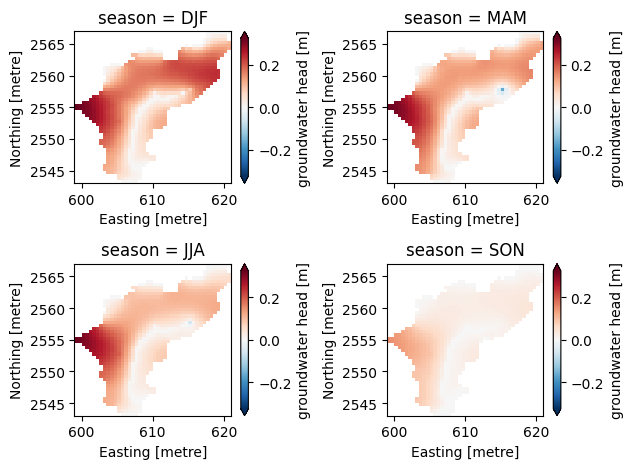

In [43]:
# Seasonal plot
import numpy as np
from matplotlib import pyplot as plt, colors

var = 'anom'
minval, maxval = ds_season_agg_2d[var].min(skipna=True).values, ds_season_agg_2d[var].max(skipna=True).values
fig, axes = plt.subplots(nrows=2, ncols=2)
axes = axes.ravel()
for i, season in enumerate(("DJF", "MAM", "JJA", "SON")):
    ds_season_agg_2d[var].sel(season=season).plot.pcolormesh(
            # x="x", y="lat",
            ax=axes[i],
            # cmap="Spectral",
            # vmin=minval, vmax=maxval,
            norm=colors.CenteredNorm(halfrange=np.max(np.abs([minval, maxval]))),
            add_colorbar=True,
            extend="both",
        )
plt.tight_layout()